# RAG Agent — Results Analysis
LiU Housing Q&A Agent | Course 732A81 Text Mining

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 130
matplotlib.rcParams['font.family'] = 'sans-serif'

with open('../eval/results.json') as f:
    results = json.load(f)

with open('../eval/ablation_results.json') as f:
    ablation = json.load(f)

summary = results['summary']
details = pd.DataFrame(results['detail'])
ablation_df = pd.DataFrame(ablation)

print('Loaded results for', summary['n_questions'], 'questions')

Loaded results for 25 questions


## 1. Overall scores

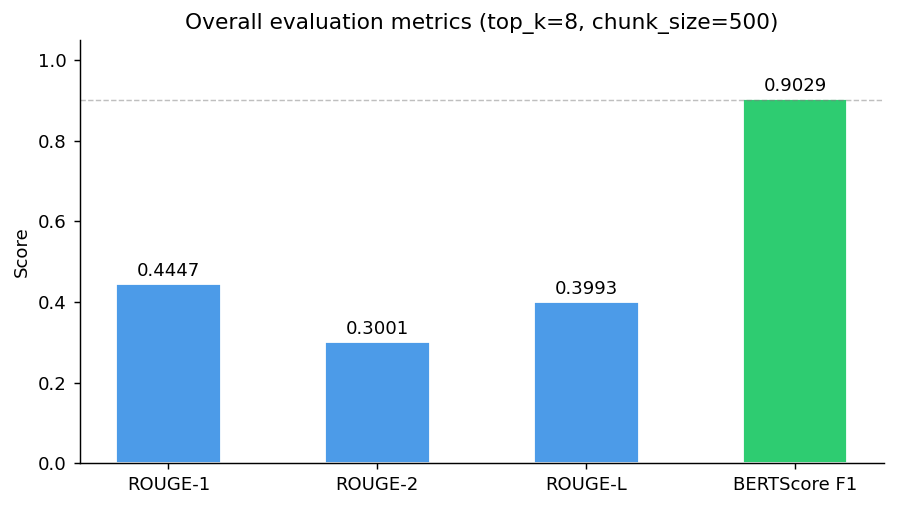

In [2]:
metrics = {
    'ROUGE-1': summary['rouge1'],
    'ROUGE-2': summary['rouge2'],
    'ROUGE-L': summary['rougeL'],
    'BERTScore F1': summary['bertscore_f1_avg'],
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#4C9BE8', '#4C9BE8', '#4C9BE8', '#2ECC71'],
              width=0.5, edgecolor='white')

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Overall evaluation metrics (top_k=8, chunk_size=500)')
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../report/figures/overall_metrics.png', bbox_inches='tight')
plt.show()

## 2. BERTScore F1 per category

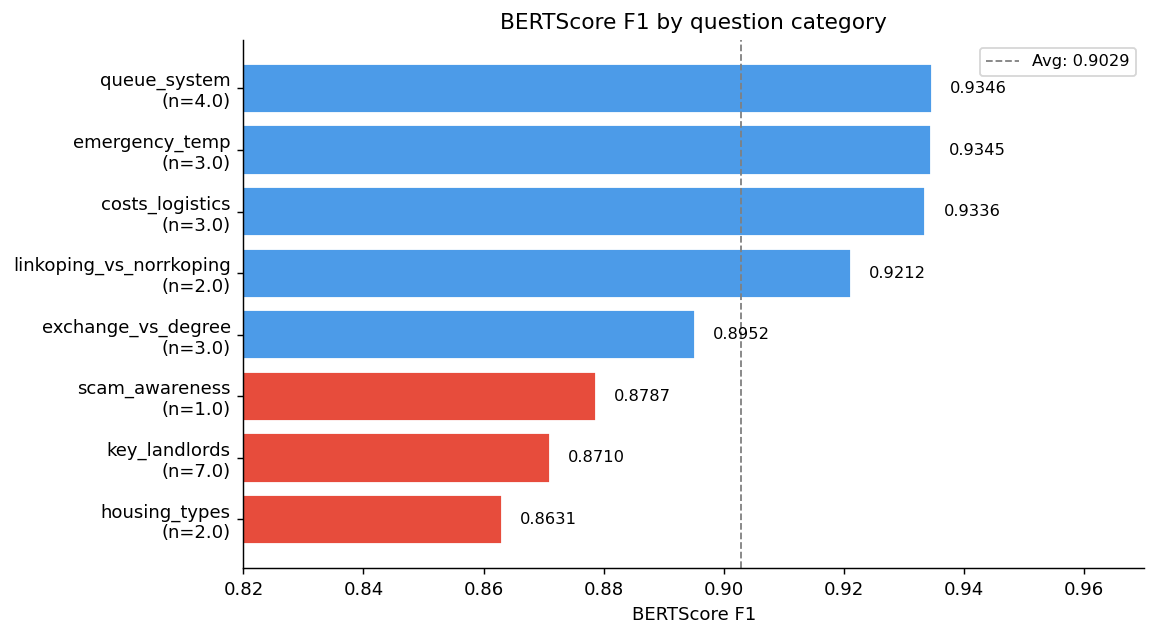

In [3]:
cat_df = (
    details.groupby('category')['bertscore_f1']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_f1', 'count': 'n'})
    .sort_values('avg_f1')
)

labels = [f"{idx}\n(n={row['n']})" for idx, row in cat_df.iterrows()]
colors = ['#E74C3C' if v < 0.88 else '#4C9BE8' for v in cat_df['avg_f1']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, cat_df['avg_f1'], color=colors, edgecolor='white')

for bar, val in zip(bars, cat_df['avg_f1']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlim(0.82, 0.97)
ax.axvline(x=summary['bertscore_f1_avg'], color='gray',
           linestyle='--', linewidth=1, label=f"Avg: {summary['bertscore_f1_avg']}")
ax.set_xlabel('BERTScore F1')
ax.set_title('BERTScore F1 by question category')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../report/figures/category_bertscore.png', bbox_inches='tight')
plt.show()

## 3. Ablation study

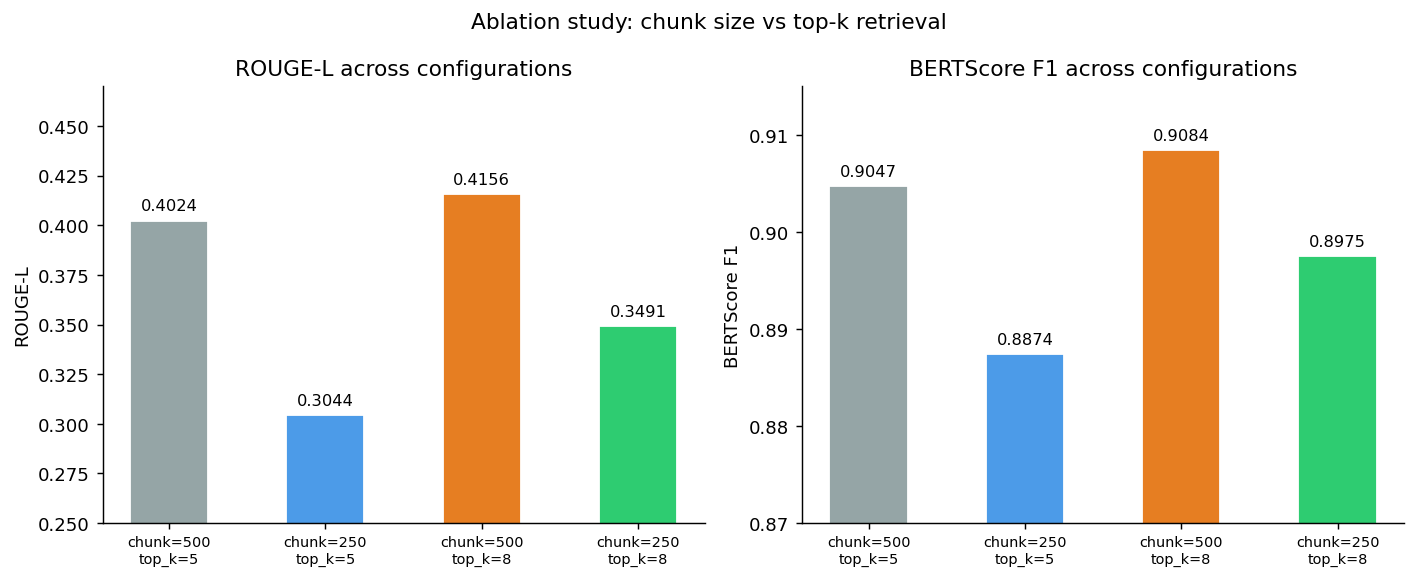

                      config  n_chunks  rouge1  rougeL  bertscore_f1
chunk=500 overlap=80 top_k=5       112  0.4412  0.4024        0.9047
chunk=250 overlap=40 top_k=5       240  0.3303  0.3044        0.8874
chunk=500 overlap=80 top_k=8       112  0.4758  0.4156        0.9084
chunk=250 overlap=40 top_k=8       240  0.3952  0.3491        0.8975


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(ablation_df))
labels = [f"chunk={r['chunk_size']}\ntop_k={r['top_k']}" for _, r in ablation_df.iterrows()]
colors = ['#95A5A6', '#4C9BE8', '#E67E22', '#2ECC71']

# ROUGE-L
axes[0].bar(x, ablation_df['rougeL'], color=colors, width=0.5, edgecolor='white')
for i, val in enumerate(ablation_df['rougeL']):
    axes[0].text(i, val + 0.005, f'{val:.4f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylim(0.25, 0.47)
axes[0].set_title('ROUGE-L across configurations')
axes[0].set_ylabel('ROUGE-L')
axes[0].spines[['top', 'right']].set_visible(False)

# BERTScore
axes[1].bar(x, ablation_df['bertscore_f1'], color=colors, width=0.5, edgecolor='white')
for i, val in enumerate(ablation_df['bertscore_f1']):
    axes[1].text(i, val + 0.001, f'{val:.4f}', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylim(0.87, 0.915)
axes[1].set_title('BERTScore F1 across configurations')
axes[1].set_ylabel('BERTScore F1')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Ablation study: chunk size vs top-k retrieval', fontsize=12)
plt.tight_layout()
plt.savefig('../report/figures/ablation.png', bbox_inches='tight')
plt.show()

print(ablation_df[['config', 'n_chunks', 'rouge1', 'rougeL', 'bertscore_f1']].to_string(index=False))

## 4. Worst performing answers — qualitative error analysis

In [5]:
worst = details.sort_values('bertscore_f1').head(5)

for _, row in worst.iterrows():
    print(f"Q{int(row['id'])} [{row['category']}]  BERTScore: {row['bertscore_f1']}")
    print(f"  Question:    {row['question']}")
    print(f"  Gold answer: {row['gold_answer']}")
    print(f"  Predicted:   {row['predicted']}")
    print()

Q25 [queue_system]  BERTScore: 0.8222
  Question:    What is the tip given to prospective students about joining housing queues?
  Gold answer: It is recommended to start joining queues as soon as you are seriously considering studying at LiU. It does not cost anything and you are not obligated to rent, but having more queue points gives you more accommodation options.
  Predicted:   Join some queue's today!

Q23 [key_landlords]  BERTScore: 0.8263
  Question:    What is Qasa?
  Gold answer: Qasa is a housing company where you can rent both furnished and unfurnished rooms, available in both Linköping and Norrköping.
  Predicted:   I don't have that information. The context only mentions "queue-points system" in the context of registering with companies for accommodation hunting, but it does not mention anything about a company or organization called "Qasa".

Q17 [key_landlords]  BERTScore: 0.8441
  Question:    What is Colonia and who is eligible to live there?
  Gold answer: Colonia is

## 5. Error pattern classification

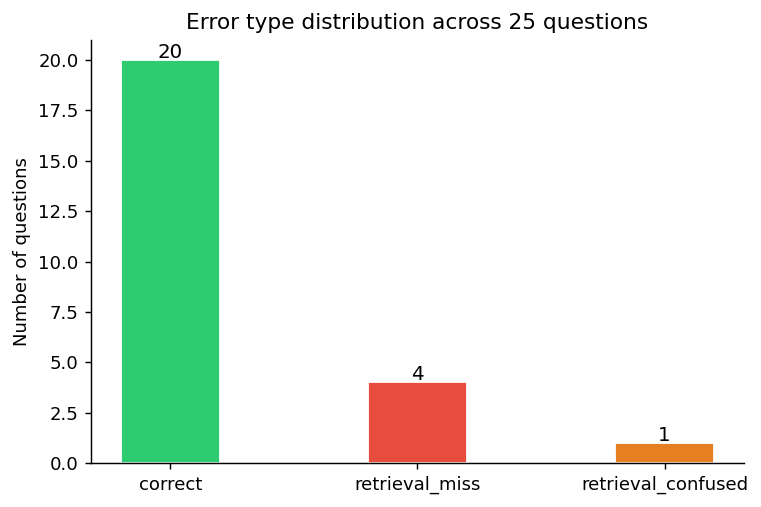


Correct:             20 / 25
Retrieval miss:      4 / 25
Retrieval confused:  1 / 25


In [6]:
# Manually tag each of the worst answers with an error type
# Types: 'retrieval_miss', 'retrieval_confused', 'correct'
error_tags = {
    23: 'retrieval_miss',
    18: 'retrieval_miss',
    8:  'retrieval_miss',
    16: 'retrieval_miss',
    19: 'retrieval_confused',
}

details['error_type'] = details['id'].map(error_tags).fillna('correct')

error_counts = details['error_type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors_e = {'correct': '#2ECC71', 'retrieval_miss': '#E74C3C', 'retrieval_confused': '#E67E22'}
bars = ax.bar(error_counts.index, error_counts.values,
              color=[colors_e[k] for k in error_counts.index],
              width=0.4, edgecolor='white')

for bar, val in zip(bars, error_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', fontsize=11)

ax.set_ylabel('Number of questions')
ax.set_title('Error type distribution across 25 questions')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../report/figures/error_types.png', bbox_inches='tight')
plt.show()

print(f"\nCorrect:             {error_counts.get('correct', 0)} / {len(details)}")
print(f"Retrieval miss:      {error_counts.get('retrieval_miss', 0)} / {len(details)}")
print(f"Retrieval confused:  {error_counts.get('retrieval_confused', 0)} / {len(details)}")

## 6. BERTScore distribution
Shows spread of scores across all questions

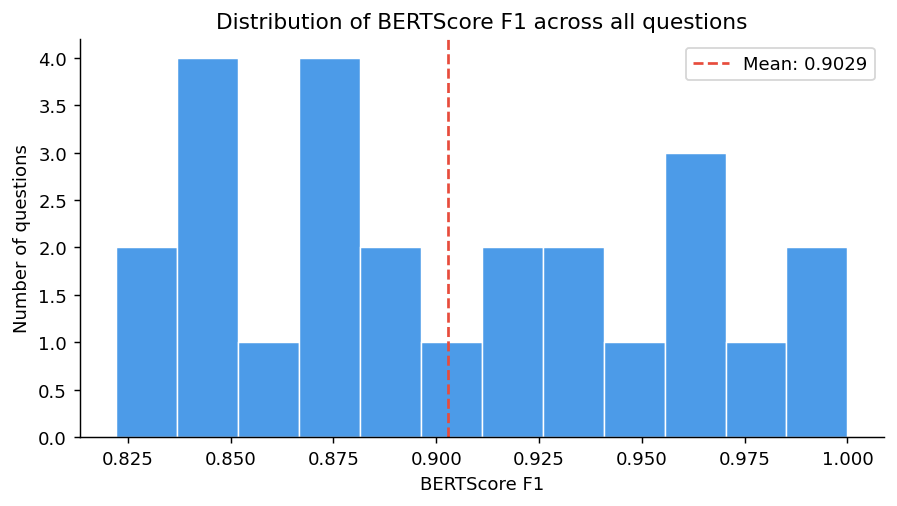

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(details['bertscore_f1'], bins=12, color='#4C9BE8',
        edgecolor='white', linewidth=0.8)
ax.axvline(details['bertscore_f1'].mean(), color='#E74C3C',
           linestyle='--', linewidth=1.5,
           label=f"Mean: {details['bertscore_f1'].mean():.4f}")
ax.set_xlabel('BERTScore F1')
ax.set_ylabel('Number of questions')
ax.set_title('Distribution of BERTScore F1 across all questions')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../report/figures/bertscore_distribution.png', bbox_inches='tight')
plt.show()